# Statistics for International Commerce
## Week 5 In-Class Practice Lab: Continuous Distributions

This notebook is designed for Google Colab.

Topics:
- Continuous probability distributions
- Uniform distribution
- Normal distribution
- Z-scores
- Probabilities under the normal curve
- Normal approximation to the binomial


## Instructions for students

1. Run each code cell with Shift + Enter.
2. Answer the questions after each task.
3. For every problem, write a short business interpretation.
4. Focus not only on calculation, but also on the decision implied by the result.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm, binom

plt.rcParams["figure.dpi"] = 140
plt.rcParams["figure.figsize"] = (8, 4.5)

## Part 1. Uniform distribution: delivery waiting time

A logistics company tells clients that customs clearance time for a standard shipment is equally likely to take any value between 2 and 10 hours.

Let:

X = customs clearance time in hours

Assume:

X ~ Uniform(2, 10)

### Task 1A
Compute the mean and standard deviation of clearance time.

In [2]:
a = 2
b = 10

mean_uniform = (a + b) / 2
std_uniform = (b - a) / np.sqrt(12)

mean_uniform, std_uniform

(6.0, np.float64(2.3094010767585034))

### Task 1B
What is the probability that clearance takes more than 8 hours?

In [3]:
prob_more_8 = (10 - 8) / (10 - 2)
prob_more_8

0.25

### Task 1C
What is the probability that clearance takes between 4 and 6 hours?

In [4]:
prob_4_6 = (6 - 4) / (10 - 2)
prob_4_6

0.25

### Task 1D
Draw the uniform distribution and shade the interval from 4 to 6 hours.

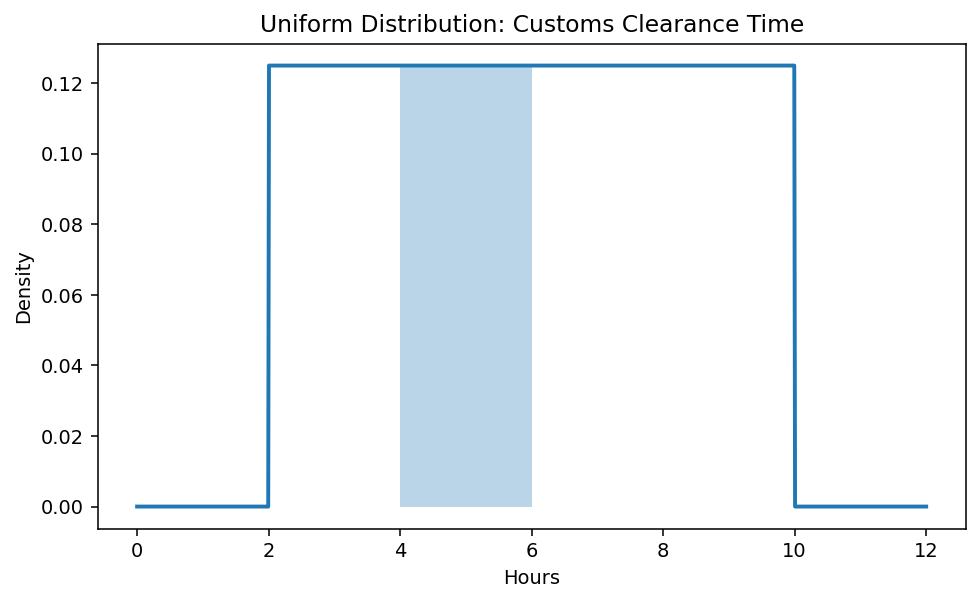

In [5]:
x = np.linspace(0, 12, 1000)
y = np.where((x >= a) & (x <= b), 1/(b-a), 0)

plt.plot(x, y, linewidth=2)
xs = np.linspace(4, 6, 200)
ys = np.full_like(xs, 1/(b-a))
plt.fill_between(xs, ys, alpha=0.3)
plt.title("Uniform Distribution: Customs Clearance Time")
plt.xlabel("Hours")
plt.ylabel("Density")
plt.show()

### Your answer
If a firm promises delivery within 8 hours, does that look risky?
Explain using the probability you calculated.

## Part 2. Normal distribution: weekly sales revenue

A company selling imported products in Korea observes that its weekly revenue is approximately normally distributed with:

- mean = 50,000 USD
- standard deviation = 8,000 USD

Let:

X = weekly revenue

### Task 2A
What is the z-score for a week with revenue of 62,000 USD?

In [6]:
mu = 50000
sigma = 8000
x_val = 62000

z_62000 = (x_val - mu) / sigma
z_62000

1.5

### Task 2B
What is the probability that weekly revenue is below 62,000 USD?

In [7]:
prob_below_62000 = norm.cdf(62000, loc=mu, scale=sigma)
prob_below_62000

np.float64(0.9331927987311419)

### Task 2C
What is the probability that weekly revenue is between 45,000 and 60,000 USD?

In [8]:
prob_45_60 = norm.cdf(60000, loc=mu, scale=sigma) - norm.cdf(45000, loc=mu, scale=sigma)
prob_45_60

np.float64(0.6283646972844441)

### Task 2D
Plot the normal distribution and shade the area between 45,000 and 60,000.

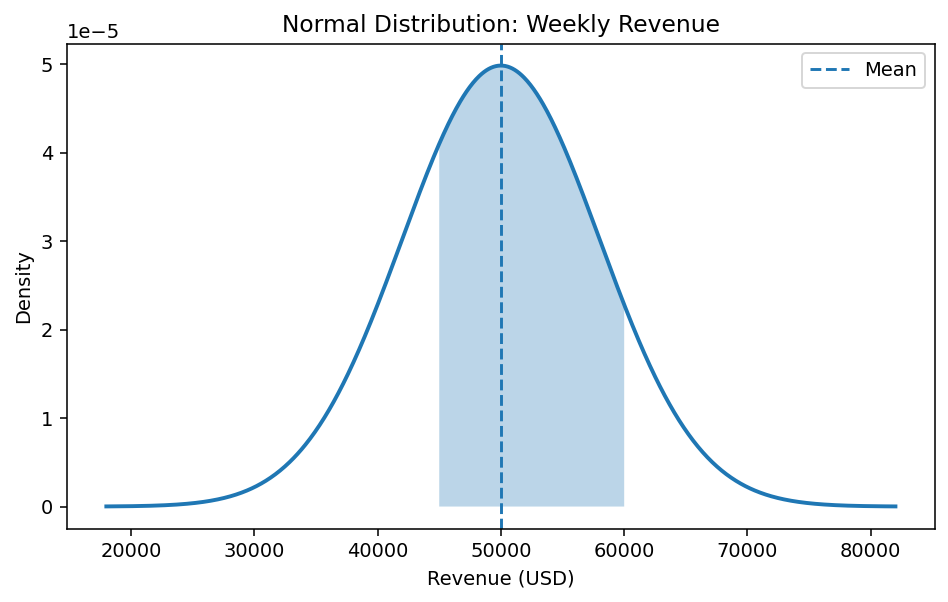

In [9]:
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, loc=mu, scale=sigma)

plt.plot(x, y, linewidth=2)

xs = np.linspace(45000, 60000, 400)
ys = norm.pdf(xs, loc=mu, scale=sigma)
plt.fill_between(xs, ys, alpha=0.3)

plt.axvline(mu, linestyle="--", label="Mean")
plt.title("Normal Distribution: Weekly Revenue")
plt.xlabel("Revenue (USD)")
plt.ylabel("Density")
plt.legend()
plt.show()

### Your answer
If the company needs at least 45,000 USD per week to cover costs, does the revenue distribution suggest a safe or risky business situation?

## Part 3. Normal distribution: shipping cost overrun

A firm importing electronics finds that extra shipping cost per container is normally distributed with:

- mean = 120 USD
- standard deviation = 30 USD

Let:

X = extra shipping cost per container

### Task 3A
What is the probability that the extra shipping cost is more than 170 USD?

In [10]:
mu_cost = 120
sigma_cost = 30

prob_more_170 = 1 - norm.cdf(170, loc=mu_cost, scale=sigma_cost)
prob_more_170

np.float64(0.047790352272814696)

### Task 3B
What is the probability that the extra shipping cost is less than 100 USD?

In [11]:
prob_less_100 = norm.cdf(100, loc=mu_cost, scale=sigma_cost)
prob_less_100

np.float64(0.2524925375469229)

### Task 3C
What is the probability that the extra shipping cost is between 100 and 150 USD?

In [12]:
prob_100_150 = norm.cdf(150, loc=mu_cost, scale=sigma_cost) - norm.cdf(100, loc=mu_cost, scale=sigma_cost)
prob_100_150

np.float64(0.58885220852162)

### Your answer
A logistics manager wants to set aside a reserve budget only for unusually high extra shipping costs.
Based on your results, does 170 USD seem like a rare event or a common one?

## Part 4. Finding X from a probability: warranty policy

A global tire producer sells in several foreign markets.

Tire lifetime is normally distributed with:

- mean = 67,900 miles
- standard deviation = 2,050 miles

Management wants to set a mileage guarantee so that only 4% of tires are expected to fail before the guarantee threshold.

### Task 4A
Find the z-value corresponding to the lower-tail probability of 0.04.

In [13]:
z_04 = norm.ppf(0.04)
z_04

np.float64(-1.75068607125217)

### Task 4B
Convert this z-value into the mileage guarantee X.

In [14]:
mu_mileage = 67900
sigma_mileage = 2050

x_guarantee = mu_mileage + z_04 * sigma_mileage
x_guarantee

np.float64(64311.09355393305)

### Your answer
Why might a company choose a guarantee based on a small lower-tail probability rather than on the mean mileage?

## Part 5. Normal approximation to the binomial: returning international customers

An international restaurant chain finds that 70% of first-time foreign customers return for another meal.

In one week, 80 first-time foreign customers visited.

Let:

X = number of those customers who return

### Task 5A
Check whether the normal approximation to the binomial is reasonable.
You need to compute:

- np
- n(1-p)

In [15]:
n = 80
p = 0.70

np_val = n * p
nq_val = n * (1 - p)

np_val, nq_val

(56.0, 24.000000000000004)

### Task 5B
Use the exact binomial distribution to compute:

P(X >= 60)

In [16]:
prob_exact = 1 - binom.cdf(59, n, p)
prob_exact

np.float64(0.19784657733914024)

### Task 5C
Now use the normal approximation with continuity correction.

Step 1: Compute mean and standard deviation.

Step 2: Use 59.5 as the cutoff.

In [17]:
mu_bin = n * p
sigma_bin = np.sqrt(n * p * (1 - p))

z_595 = (59.5 - mu_bin) / sigma_bin
prob_approx = 1 - norm.cdf(59.5, loc=mu_bin, scale=sigma_bin)

mu_bin, sigma_bin, z_595, prob_approx

(56.0,
 np.float64(4.09878030638384),
 np.float64(0.8539125638299665),
 np.float64(0.19657671883700156))

### Task 5D
Compare the exact probability and the approximation.

In [18]:
comparison = pd.DataFrame({
    "Method": ["Exact binomial", "Normal approximation"],
    "Probability": [prob_exact, prob_approx]
})

comparison

,Method,Probability
0,Exact binomial,0.197847
1,Normal approximation,0.196577


### Your answer
If management is planning table capacity and repeat-customer promotions, is the event 60 or more return customers rare or fairly realistic?
Use the probability result to justify your answer.

## Part 6. Short interpretation task

Write short answers to the following:

1. In international commerce, when is a uniform distribution a useful approximation?
2. Why is the normal distribution so important in business statistics?
3. Why do we use a continuity correction when approximating a binomial distribution by a normal distribution?

## Part 7. Mini decision case

A company expanding across Asia is concerned about:

- customs delays
- weak sales weeks
- unusually high shipping cost overruns
- uncertainty about repeat customers

Based on your results in this notebook:

1. Which risk seems the most serious?
2. Which one seems the most predictable?
3. What one operational change would you recommend first?

Write 4 to 6 sentences.

## End of lab

Before submitting:
- run all cells
- make sure your answers are complete
- save your notebook in Google Drive